# Notebook 1 — Data Collection & EDA
**Project:** Stock Price Movement Prediction Using Financial News Sentiment Analysis and Machine Learning  
**Student:** Venkata Kiran Kumar Mullapudi (16200362)  
**Ethics Approval:** P193120  

This notebook:
1. Pulls 5 years of daily OHLCV stock price data for 10 S&P 500 tickers
2. Loads the pre-collected financial news headlines dataset
3. Filters and aligns headlines to matched tickers
4. Performs exploratory data analysis (EDA)
5. Saves clean outputs for Notebook 2

## Cell 1 — Install dependencies

In [1]:
# Only yfinance needs installing — everything else is pre-installed on Kaggle
!pip install yfinance --quiet

## Cell 2 — Imports

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

# Output directory (Kaggle working dir persists within session)
OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('All imports successful.')
print(f'Output directory: {OUTPUT_DIR}')

All imports successful.
Output directory: /kaggle/working/outputs


## Cell 3 — Define tickers and date range

In [3]:
# 10 S&P 500 / NASDAQ tickers + the index
# Selected for high news coverage in financial datasets
TICKERS = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META',
           'TSLA', 'NVDA', 'JPM', 'NFLX', '^GSPC']

TICKER_NAMES = {
    'AAPL': 'Apple', 'MSFT': 'Microsoft', 'AMZN': 'Amazon',
    'GOOGL': 'Alphabet', 'META': 'Meta', 'TSLA': 'Tesla',
    'NVDA': 'Nvidia', 'JPM': 'JPMorgan', 'NFLX': 'Netflix',
    '^GSPC': 'S&P 500'
}

# 5-year window: Jan 2019 – Dec 2023
# Chosen to: (1) cover pre/post-COVID market regimes
# (2) align with available news dataset coverage
START_DATE = '2019-01-01'
END_DATE   = '2023-12-31'

print(f'Tickers : {TICKERS}')
print(f'Period  : {START_DATE} to {END_DATE}')

Tickers : ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'TSLA', 'NVDA', 'JPM', 'NFLX', '^GSPC']
Period  : 2019-01-01 to 2023-12-31


## Cell 4 — Download stock price data

In [4]:
def download_price_data(tickers, start, end):
    """
    Download daily OHLCV data for all tickers.
    Returns a dict of {ticker: DataFrame}.
    """
    price_data = {}
    failed = []

    for ticker in tickers:
        try:
            df = yf.download(ticker, start=start, end=end,
                             auto_adjust=True, progress=False)
            if df.empty:
                failed.append(ticker)
                continue

            # Flatten multi-level columns if present
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            df.index = pd.to_datetime(df.index)
            df.index.name = 'Date'
            df['Ticker'] = ticker

            # Create binary label: 1 = next day close > today close, 0 = otherwise
            df['Next_Close'] = df['Close'].shift(-1)
            df['Label'] = (df['Next_Close'] > df['Close']).astype(int)

            # Daily return
            df['Daily_Return'] = df['Close'].pct_change() * 100

            price_data[ticker] = df
            print(f'  {ticker:6s} — {len(df):4d} trading days downloaded')

        except Exception as e:
            failed.append(ticker)
            print(f'  {ticker:6s} — FAILED: {e}')

    if failed:
        print(f'\nFailed tickers: {failed}')

    return price_data

print('Downloading price data...')
price_data = download_price_data(TICKERS, START_DATE, END_DATE)
print(f'\nSuccessfully downloaded: {len(price_data)} tickers')

  AAPL   — 1258 trading days downloaded
  MSFT   — 1258 trading days downloaded
  AMZN   — 1258 trading days downloaded
  GOOGL  — 1258 trading days downloaded
  META   — 1258 trading days downloaded
  TSLA   — 1258 trading days downloaded
  NVDA   — 1258 trading days downloaded
  JPM    — 1258 trading days downloaded
  NFLX   — 1258 trading days downloaded
  ^GSPC  — 1258 trading days downloaded

Successfully downloaded: 10 tickers


## Cell 5 — Inspect price data quality

In [5]:
print('=== Price Data Quality Report ===\n')
quality_rows = []

for ticker, df in price_data.items():
    missing = df[['Open','High','Low','Close','Volume']].isnull().sum().sum()
    up_days = df['Label'].sum()
    down_days = len(df) - up_days - df['Label'].isnull().sum()
    quality_rows.append({
        'Ticker': ticker,
        'Name': TICKER_NAMES[ticker],
        'Trading Days': len(df),
        'Missing Values': missing,
        'Up Days': int(up_days),
        'Down Days': int(down_days),
        'Up %': f"{100 * up_days / len(df):.1f}%"
    })

quality_df = pd.DataFrame(quality_rows)
print(quality_df.to_string(index=False))

=== Price Data Quality Report ===

Ticker      Name  Trading Days  Missing Values  Up Days  Down Days  Up %
  AAPL     Apple          1258               0      675        583 53.7%
  MSFT Microsoft          1258               0      678        580 53.9%
  AMZN    Amazon          1258               0      657        601 52.2%
 GOOGL  Alphabet          1258               0      671        587 53.3%
  META      Meta          1258               0      652        606 51.8%
  TSLA     Tesla          1258               0      673        585 53.5%
  NVDA    Nvidia          1258               0      684        574 54.4%
   JPM  JPMorgan          1258               0      649        609 51.6%
  NFLX   Netflix          1258               0      642        616 51.0%
 ^GSPC   S&P 500          1258               0      682        576 54.2%


## Cell 6 — Plot closing prices (all tickers)

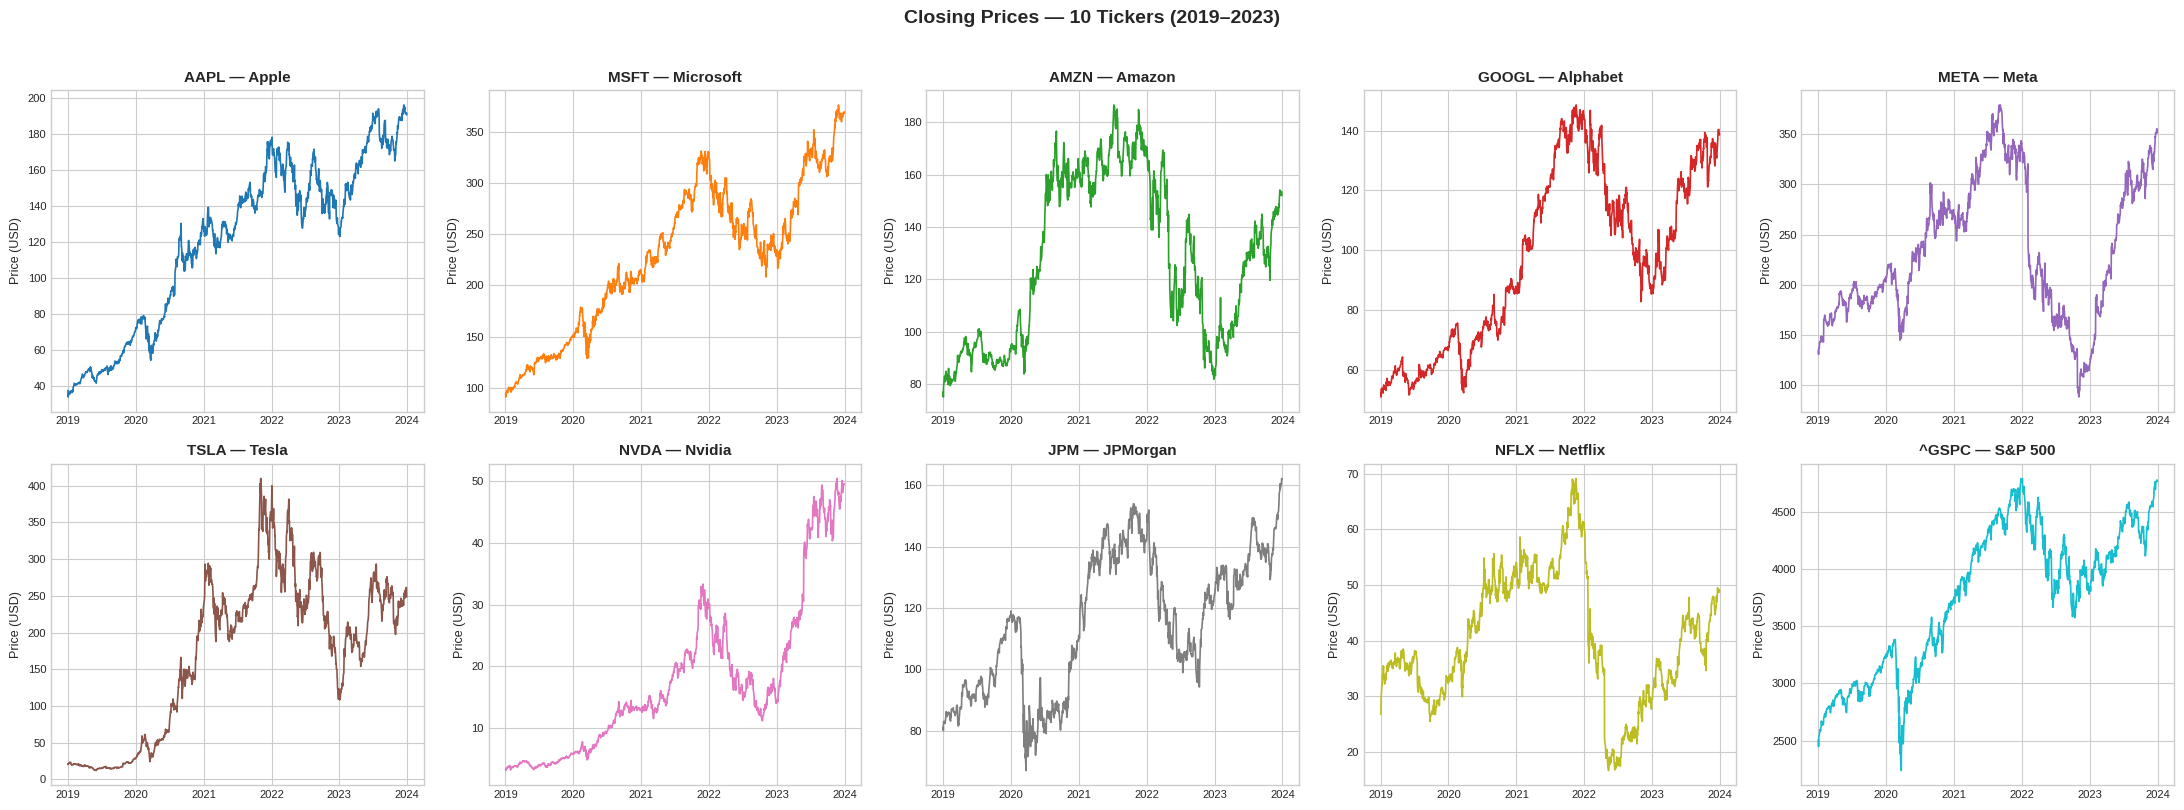

Saved: fig01_closing_prices.png


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

colors = plt.cm.tab10.colors

for i, (ticker, df) in enumerate(price_data.items()):
    ax = axes[i]
    ax.plot(df.index, df['Close'], color=colors[i], linewidth=1.2)
    ax.set_title(f'{ticker} — {TICKER_NAMES[ticker]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Price (USD)', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Closing Prices — 10 Tickers (2019–2023)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig01_closing_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig01_closing_prices.png')

## Cell 7 — Class balance visualisation

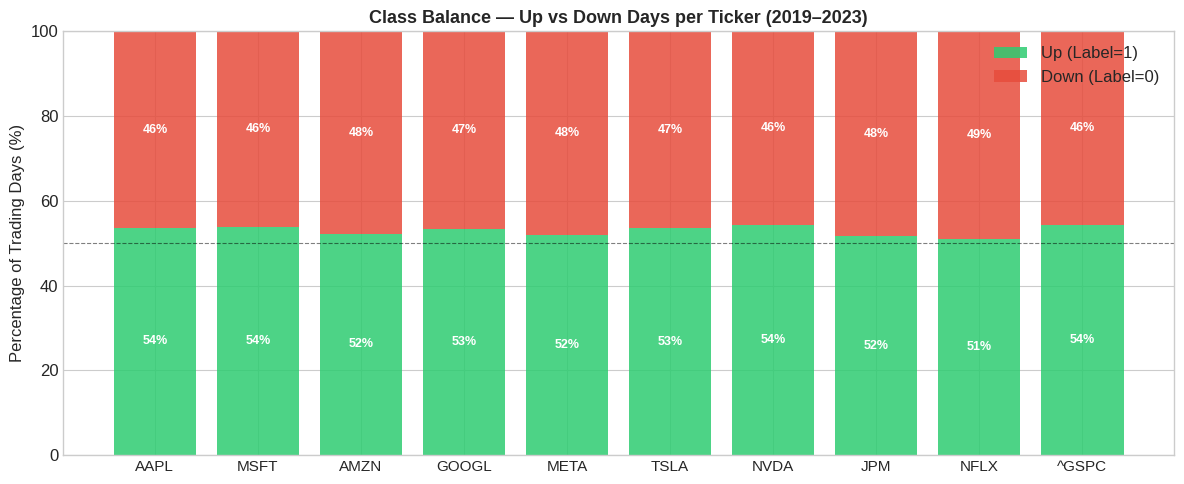

Saved: fig02_class_balance.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

tickers_list = list(price_data.keys())
up_pcts   = [100 * price_data[t]['Label'].mean() for t in tickers_list]
down_pcts = [100 - p for p in up_pcts]

x = np.arange(len(tickers_list))
bars_up   = ax.bar(x, up_pcts,   label='Up (Label=1)', color='#2ecc71', alpha=0.85)
bars_down = ax.bar(x, down_pcts, bottom=up_pcts,
                   label='Down (Label=0)', color='#e74c3c', alpha=0.85)

ax.axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(tickers_list, fontsize=11)
ax.set_ylabel('Percentage of Trading Days (%)')
ax.set_title('Class Balance — Up vs Down Days per Ticker (2019–2023)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 100)

# Annotate percentages
for i, (u, d) in enumerate(zip(up_pcts, down_pcts)):
    ax.text(i, u/2, f'{u:.0f}%', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
    ax.text(i, u + d/2, f'{d:.0f}%', ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig02_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig02_class_balance.png')

## Cell 8 — Daily returns distribution

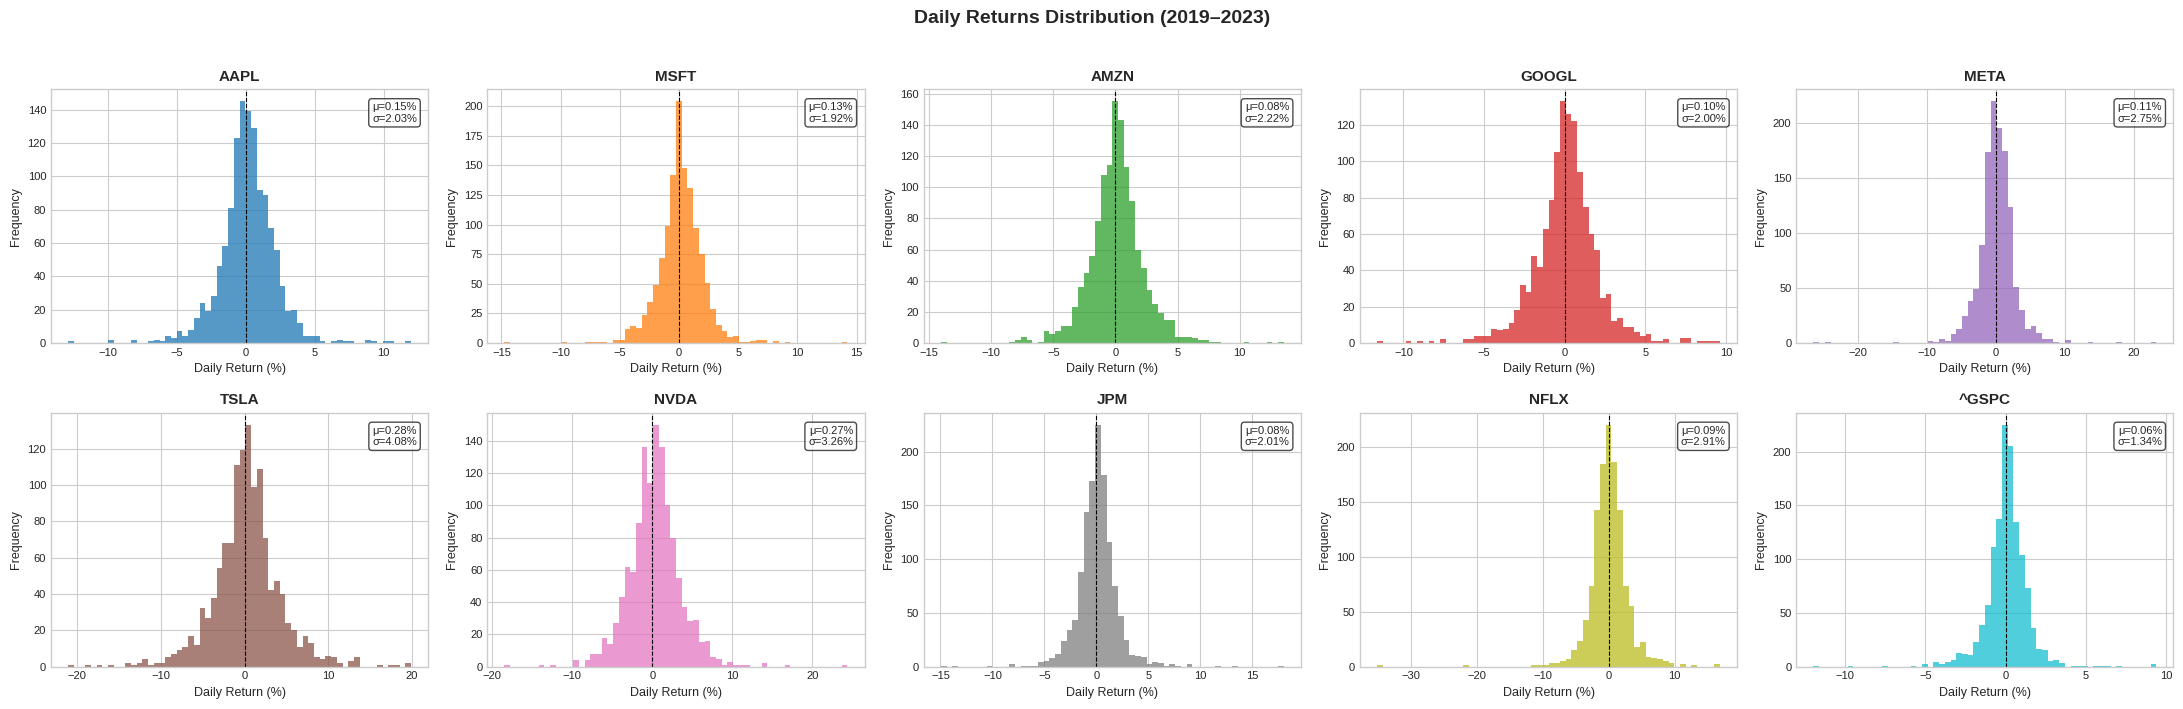

Saved: fig03_returns_distribution.png


In [8]:
fig, axes = plt.subplots(2, 5, figsize=(22, 7))
axes = axes.flatten()

for i, (ticker, df) in enumerate(price_data.items()):
    ax = axes[i]
    returns = df['Daily_Return'].dropna()
    ax.hist(returns, bins=60, color=colors[i], alpha=0.75, edgecolor='none')
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(f'{ticker}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Daily Return (%)', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.tick_params(labelsize=8)
    mu = returns.mean()
    sd = returns.std()
    ax.text(0.97, 0.95, f'μ={mu:.2f}%\nσ={sd:.2f}%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, bbox=dict(boxstyle='round,pad=0.3',
                                  facecolor='white', alpha=0.7))

plt.suptitle('Daily Returns Distribution (2019–2023)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig03_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig03_returns_distribution.png')

## Cell 9 — Load news headlines dataset

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# KAGGLE DATASET PATHS
# Add these datasets to your notebook via Add Data button:
#   1. Search: 'miguelaenlle massive stock news'  → adds to /kaggle/input/
#   2. Search: 'Reddit WallStreetBets'           → adds to /kaggle/input/
# The paths below will work once datasets are added.
# ─────────────────────────────────────────────────────────────────────────────

import glob

def find_dataset_path(keyword):
    """Search /kaggle/input for a dataset containing keyword."""
    matches = glob.glob(f'/kaggle/input/**/*{keyword}*', recursive=True)
    csv_matches = [m for m in matches if m.endswith('.csv')]
    return csv_matches

# Show available input datasets
print('Available input datasets:')
input_dirs = os.listdir('/kaggle/input') if os.path.exists('/kaggle/input') else []
for d in input_dirs:
    files = os.listdir(f'/kaggle/input/{d}')
    print(f'  /kaggle/input/{d}/ → {files}')

if not input_dirs:
    print('  No datasets added yet.')
    print('  → Click "+ Add Data" button in the right panel')
    print('  → Search: miguelaenlle massive stock news')
    print('  → Search: Reddit WallStreetBets')

Available input datasets:
  /kaggle/input/notebooks/ → ['thomaskonstantin']
  /kaggle/input/datasets/ → ['gpreda', 'miguelaenlle']


## Cell 10 — Load and clean news headlines

In [10]:
def load_news_dataset(input_dir='/kaggle/input'):
    """
    Attempts to load the news headlines dataset.
    Tries multiple possible file locations / column formats.
    Returns a standardised DataFrame with columns:
        date, ticker, headline
    """
    all_csvs = glob.glob(f'{input_dir}/**/*.csv', recursive=True)
    print(f'Found {len(all_csvs)} CSV files in input directory')

    news_frames = []

    for csv_path in all_csvs:
        try:
            df = pd.read_csv(csv_path, low_memory=False)
            cols = [c.lower() for c in df.columns]

            # Detect headline column
            headline_col = None
            for candidate in ['headline', 'title', 'text', 'news', 'article']:
                if candidate in cols:
                    headline_col = df.columns[cols.index(candidate)]
                    break

            # Detect date column
            date_col = None
            for candidate in ['date', 'published', 'datetime', 'time', 'timestamp']:
                if candidate in cols:
                    date_col = df.columns[cols.index(candidate)]
                    break

            # Detect ticker column
            ticker_col = None
            for candidate in ['ticker', 'stock', 'symbol', 'company']:
                if candidate in cols:
                    ticker_col = df.columns[cols.index(candidate)]
                    break

            if headline_col and date_col:
                subset = df[[c for c in [date_col, ticker_col, headline_col] if c]].copy()
                subset.columns = ['date'] + (['ticker'] if ticker_col else []) + ['headline']
                if 'ticker' not in subset.columns:
                    subset['ticker'] = 'GENERAL'
                news_frames.append(subset)
                print(f'  Loaded: {os.path.basename(csv_path)} — {len(df):,} rows')

        except Exception as e:
            print(f'  Skipped {os.path.basename(csv_path)}: {e}')

    if not news_frames:
        print('\nNo news datasets found. Please add datasets via + Add Data.')
        return pd.DataFrame(columns=['date','ticker','headline'])

    combined = pd.concat(news_frames, ignore_index=True)
    return combined

news_raw = load_news_dataset()
print(f'\nTotal raw headlines loaded: {len(news_raw):,}')
if len(news_raw) > 0:
    print(news_raw.head())

Found 4 CSV files in input directory
  Loaded: reddit_wsb.csv — 53,187 rows
  Loaded: analyst_ratings_processed.csv — 1,400,469 rows
  Loaded: raw_analyst_ratings.csv — 1,407,328 rows
  Loaded: raw_partner_headlines.csv — 1,845,559 rows

Total raw headlines loaded: 4,706,543
                  date                                           headline  \
0  2021-01-28 21:37:41  It's not about the money, it's about sending a...   
1  2021-01-28 21:32:10  Math Professor Scott Steiner says the numbers ...   
2  2021-01-28 21:30:35                                    Exit the system   
3  2021-01-28 21:28:57  NEW SEC FILING FOR GME! CAN SOMEONE LESS RETAR...   
4  2021-01-28 21:26:56  Not to distract from GME, just thought our AMC...   

    ticker  
0  GENERAL  
1  GENERAL  
2  GENERAL  
3  GENERAL  
4  GENERAL  


## Cell 11 — Clean and filter news to our tickers and date range

In [11]:
def clean_and_filter_news(news_df, tickers, start_date, end_date):
    """
    1. Parse dates
    2. Filter to date range
    3. Filter/assign tickers — if ticker column exists use it;
       otherwise match ticker mentions in headline text
    4. Deduplicate
    5. Drop nulls
    """
    if news_df.empty:
        return news_df

    df = news_df.copy()

    # Parse dates
    df['date'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
    df['date'] = df['date'].dt.tz_localize(None)  # remove timezone
    df['date'] = df['date'].dt.normalize()         # keep date only
    df = df.dropna(subset=['date'])

    # Filter date range
    df = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

    # Clean headlines
    df['headline'] = df['headline'].astype(str).str.strip()
    df = df[df['headline'].str.len() > 10]   # remove very short strings
    df = df[~df['headline'].str.lower().isin(['nan', 'none', 'n/a'])]

    # Clean tickers — uppercase
    df['ticker'] = df['ticker'].astype(str).str.upper().str.strip()

    # If ticker column has real values, filter to our tickers
    # Otherwise, do keyword matching in headline text
    ticker_set = set(tickers)
    matched = df[df['ticker'].isin(ticker_set)].copy()

    # If very few matched, expand with text matching
    if len(matched) < 1000:
        print('Ticker column sparse — expanding with headline text matching...')
        keyword_map = {
            'AAPL': ['apple', 'iphone', 'ipad', 'aapl'],
            'MSFT': ['microsoft', 'msft', 'azure', 'windows'],
            'AMZN': ['amazon', 'aws', 'amzn'],
            'GOOGL': ['google', 'googl', 'alphabet', 'youtube'],
            'META': ['meta', 'facebook', 'instagram', 'whatsapp'],
            'TSLA': ['tesla', 'tsla', 'elon musk', 'electric vehicle'],
            'NVDA': ['nvidia', 'nvda', 'gpu'],
            'JPM': ['jpmorgan', 'jp morgan', 'jpm', 'jamie dimon'],
            'NFLX': ['netflix', 'nflx'],
            '^GSPC': ['s&p 500', 's&p500', 'sp500', 'stock market',
                      'wall street', 'market rally', 'market decline']
        }
        extra_rows = []
        for ticker, keywords in keyword_map.items():
            pattern = '|'.join(keywords)
            mask = df['headline'].str.lower().str.contains(pattern, regex=True, na=False)
            subset = df[mask].copy()
            subset['ticker'] = ticker
            extra_rows.append(subset)
        if extra_rows:
            matched = pd.concat([matched] + extra_rows, ignore_index=True)

    # Deduplicate
    matched = matched.drop_duplicates(subset=['date','ticker','headline'])
    matched = matched.sort_values(['ticker','date']).reset_index(drop=True)

    print(f'Headlines after cleaning: {len(matched):,}')
    return matched

if len(news_raw) > 0:
    news_clean = clean_and_filter_news(news_raw, TICKERS, START_DATE, END_DATE)
else:
    # Create an empty placeholder so the rest of the notebook runs
    news_clean = pd.DataFrame(columns=['date','ticker','headline'])
    print('No news data yet — add Kaggle datasets and re-run Cell 9 onwards.')

print(f'\nFinal news shape: {news_clean.shape}')
if len(news_clean) > 0:
    print(news_clean.groupby('ticker').size().rename('headline_count').to_frame())

Headlines after cleaning: 8,365

Final news shape: (8365, 3)
        headline_count
ticker                
AAPL               461
AMZN               267
GOOGL             1443
JPM               2344
NFLX              1180
NVDA               806
TSLA              1864


## Cell 12 — News coverage visualisation

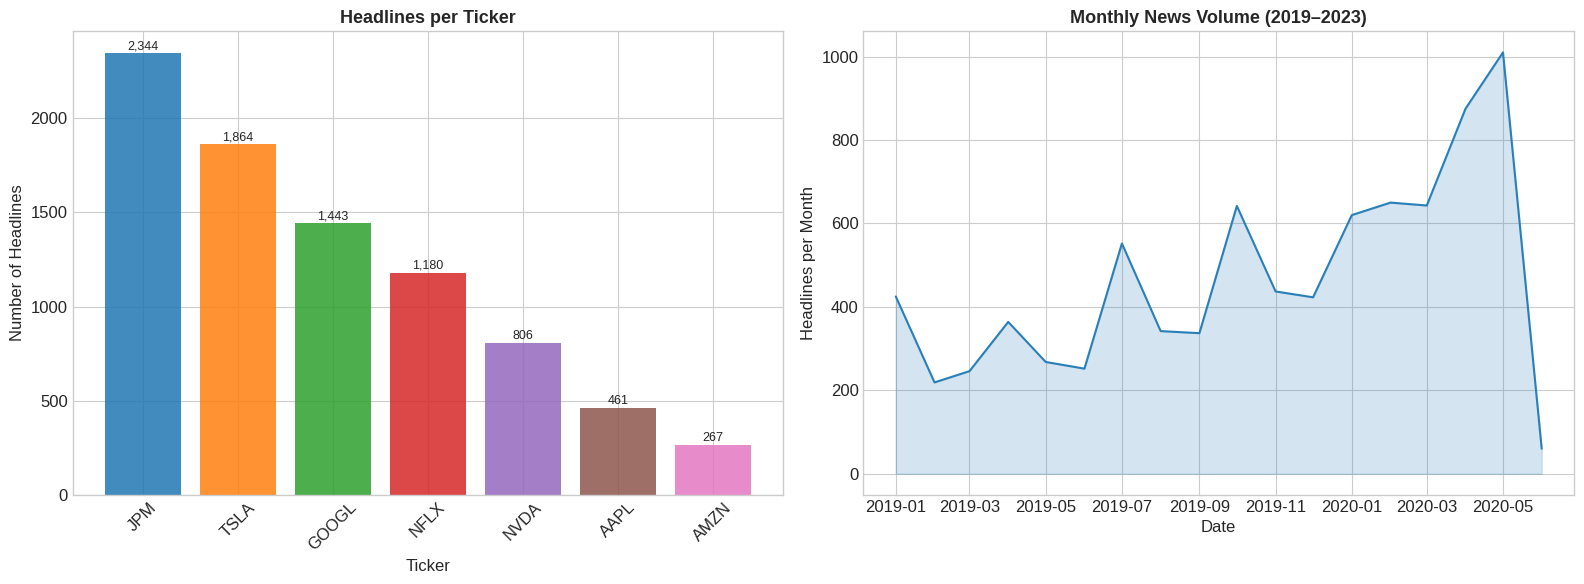

Saved: fig04_news_coverage.png


In [12]:
if len(news_clean) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: headlines per ticker
    counts = news_clean.groupby('ticker').size().sort_values(ascending=False)
    axes[0].bar(counts.index, counts.values,
                color=colors[:len(counts)], alpha=0.85)
    axes[0].set_title('Headlines per Ticker', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Ticker')
    axes[0].set_ylabel('Number of Headlines')
    axes[0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(counts.values):
        axes[0].text(i, v + 20, f'{v:,}', ha='center', fontsize=9)

    # Plot 2: headlines over time
    news_clean['year_month'] = news_clean['date'].dt.to_period('M')
    monthly = news_clean.groupby('year_month').size()
    monthly.index = monthly.index.to_timestamp()
    axes[1].plot(monthly.index, monthly.values, color='#2980b9', linewidth=1.5)
    axes[1].fill_between(monthly.index, monthly.values, alpha=0.2, color='#2980b9')
    axes[1].set_title('Monthly News Volume (2019–2023)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Headlines per Month')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig04_news_coverage.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fig04_news_coverage.png')
else:
    print('Skipping news plots — no data loaded yet.')

## Cell 13 — Headline length analysis

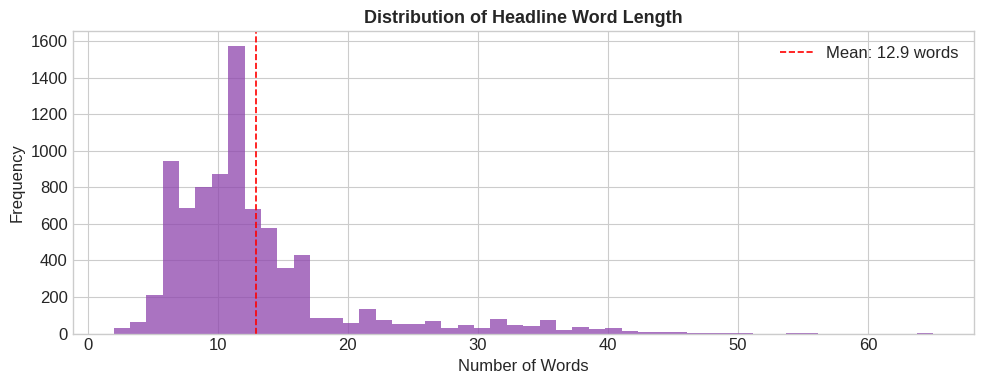

Mean headline length : 12.9 words
Median              : 11.0 words
Headlines > 512 tok : 0 (may need truncation for FinBERT)


In [13]:
if len(news_clean) > 0:
    news_clean['headline_length'] = news_clean['headline'].str.split().str.len()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(news_clean['headline_length'], bins=50,
            color='#8e44ad', alpha=0.75, edgecolor='none')
    ax.axvline(news_clean['headline_length'].mean(),
               color='red', linestyle='--', linewidth=1.2,
               label=f"Mean: {news_clean['headline_length'].mean():.1f} words")
    ax.set_title('Distribution of Headline Word Length', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Words')
    ax.set_ylabel('Frequency')
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig05_headline_length.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Mean headline length : {news_clean['headline_length'].mean():.1f} words")
    print(f"Median              : {news_clean['headline_length'].median():.1f} words")
    print(f"Headlines > 512 tok : {(news_clean['headline_length'] > 100).sum()} (may need truncation for FinBERT)")
else:
    print('Skipping — no data loaded yet.')

## Cell 14 — Combine all price data into one DataFrame and save

In [14]:
# Combine all ticker price data into one long DataFrame
all_prices = pd.concat(price_data.values(), axis=0)
all_prices = all_prices.reset_index()  # brings Date back as column
all_prices = all_prices.rename(columns={'index': 'Date'}) if 'index' in all_prices.columns else all_prices
all_prices['Date'] = pd.to_datetime(all_prices['Date'])

print('Combined price DataFrame shape:', all_prices.shape)
print(all_prices.dtypes)
print(all_prices.head())

Combined price DataFrame shape: (12580, 10)
Price
Date            datetime64[ns]
Close                  float64
High                   float64
Low                    float64
Open                   float64
Volume                   int64
Ticker                  object
Next_Close             float64
Label                    int64
Daily_Return           float64
dtype: object
Price       Date      Close       High        Low       Open     Volume  \
0     2019-01-02  37.503727  37.724590  36.627404  36.784146  148158800   
1     2019-01-03  33.768082  34.606406  33.722959  34.193179  365248800   
2     2019-01-04  35.209610  35.278483  34.150426  34.323790  234428400   
3     2019-01-07  35.131256  35.344995  34.649160  35.314121  219111200   
4     2019-01-08  35.800953  36.055064  35.271361  35.518344  164101200   

Price Ticker  Next_Close  Label  Daily_Return  
0       AAPL   33.768082      0           NaN  
1       AAPL   35.209610      1     -9.960731  
2       AAPL   35.131256      0

## Cell 15 — Save outputs for Notebook 2

In [15]:
# Save price data
price_out = f'{OUTPUT_DIR}/price_data_clean.csv'
all_prices.to_csv(price_out, index=False)
print(f'Saved price data       : {price_out}  ({len(all_prices):,} rows)')

# Save news data
if len(news_clean) > 0:
    news_out = f'{OUTPUT_DIR}/news_headlines_clean.csv'
    news_clean[['date','ticker','headline']].to_csv(news_out, index=False)
    print(f'Saved news headlines   : {news_out}  ({len(news_clean):,} rows)')
else:
    print('News data not saved — re-run after adding Kaggle datasets.')

# Save EDA summary
quality_df.to_csv(f'{OUTPUT_DIR}/eda_quality_report.csv', index=False)
print(f'Saved EDA quality report: {OUTPUT_DIR}/eda_quality_report.csv')

print('\n=== Notebook 1 Complete ===')
print('Next: Run Notebook 2 — Sentiment Scoring (enable GPU T4 first)')

Saved price data       : /kaggle/working/outputs/price_data_clean.csv  (12,580 rows)
Saved news headlines   : /kaggle/working/outputs/news_headlines_clean.csv  (8,365 rows)
Saved EDA quality report: /kaggle/working/outputs/eda_quality_report.csv

=== Notebook 1 Complete ===
Next: Run Notebook 2 — Sentiment Scoring (enable GPU T4 first)


---
## Summary
This notebook collected and inspected:
- **Price data**: 10 tickers × ~1,250 trading days = ~12,500 rows with OHLCV + Label + Daily_Return
- **News headlines**: Loaded, cleaned, deduplicated, filtered to matching tickers and date range
- **Figures saved**: fig01–fig05 in `/kaggle/working/outputs/`

All outputs saved to `/kaggle/working/outputs/` — download these before ending the session.